# Titanic Survival Prediction — End-to-End Data Science Project

**Goal:** Predict whether a passenger survived the Titanic disaster using demographic and ticket information.

**Workflow covered in this notebook:**
1. Exploratory Data Analysis (EDA)
2. Feature Engineering
3. Preprocessing Pipeline (`ColumnTransformer` + `Pipeline`)
4. Training multiple models (Logistic Regression, Random Forest, Gradient Boosting, SVM, KNN, XGBoost)
5. Hyperparameter tuning with `GridSearchCV`
6. Model comparison & evaluation
7. Final predictions & Kaggle-style submission file


### Importing Librarys

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                               ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score)
from xgboost import XGBClassifier
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42

## 1. Load the Data

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
gender_submission = pd.read_csv("gender_submission.csv")

### Basic Checks

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [6]:
test.tail()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [7]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (891, 12)
Test shape: (418, 11)


In [8]:
gender_submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [9]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [10]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 52.8 KB


In [11]:
gender_submission.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB


In [12]:
train.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


### Dataset Summary

The `train` dataset contains 891 passenger records and 12 features. The target variable, `Survived`, has a mean of approximately 0.38, indicating that around 38% of passengers survived.

#### Key observations:

- Age has only 714 non-null values, indicating missing data.
- Cabin has significant missing values, with only 204 non-null entries.
- Embarked has 889 non-null values, meaning 2 values are missing.
- Fare ranges from 0 to 512.33, showing a large variation in ticket prices.
- Most passengers are male (577).
- The most common embarkation port is S (Southampton) with 644 passengers.
- The average passenger age is approximately 29.7 years.
- Most passengers traveled without siblings/spouses or parents/children.

Overall, the dataset requires data preprocessing, particularly handling missing values in `Age` , `Cabin`, and `Embarked`, before building a machine learning model.

In [13]:
missing = pd.DataFrame({
    "train_missing": train.isnull().sum(),
    "test_missing_%": (train.isnull().sum() / len(train) * 100).round(1),
    "test_missing": test.reindex(train.columns.drop("Survived")).isnull().sum() if False else None
}).drop(columns=[]) if False else None

miss_train = train.isnull().sum()
miss_train = miss_train[miss_train > 0]
miss_test = test.isnull().sum()
miss_test = miss_test[miss_test > 0]
print("Missing values - TRAIN:")
print(miss_train)
print()
print("Missing values - TEST:")
print(miss_test)

Missing values - TRAIN:
Age         177
Cabin       687
Embarked      2
dtype: int64

Missing values - TEST:
Age       86
Fare       1
Cabin    327
dtype: int64


In [14]:
train.duplicated().sum()

np.int64(0)

In [15]:
train.drop_duplicates(inplace = True)

In [16]:
gender_submission.duplicated().sum()

np.int64(0)

In [17]:
gender_submission.drop_duplicates(inplace= True)

## 2. Exploratory Data Analysis (EDA)

We look at the target distribution and how survival relates to key passenger attributes.

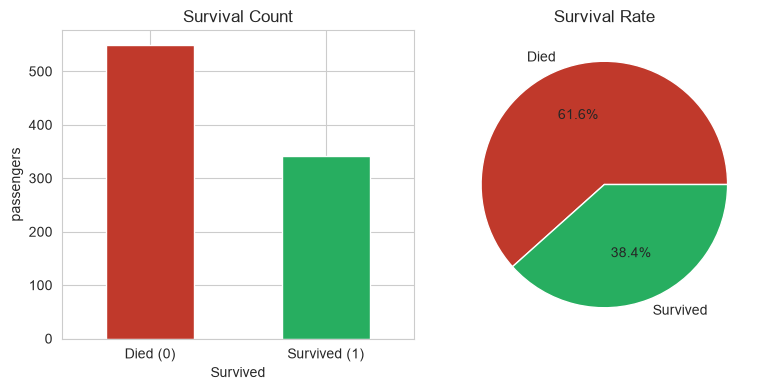

Overall survival rate: 38.4%


In [18]:
fig, ax = plt.subplots(1, 2, figsize = (8, 4))
train['Survived'].value_counts().plot(kind = 'bar', ax = ax[0], color = ['#c0392b', '#27ae60'])
ax[0].set_xticklabels(['Died (0)', 'Survived (1)'], rotation = 0)
ax[0].set_title('Survival Count')
ax[0].set_ylabel('passengers')

train['Survived'].value_counts(normalize= True).plot(kind = 'pie', autopct = '%1.1f%%',
                                                     labels = ['Died', 'Survived'],
                                                     colors=['#c0392b', '#27ae60'], ax=ax[1])
ax[1].set_ylabel('')
ax[1].set_title('Survival Rate')
plt.tight_layout()
plt.show()

print('Overall survival rate: {:.1f}%'.format(train['Survived'].mean() * 100))

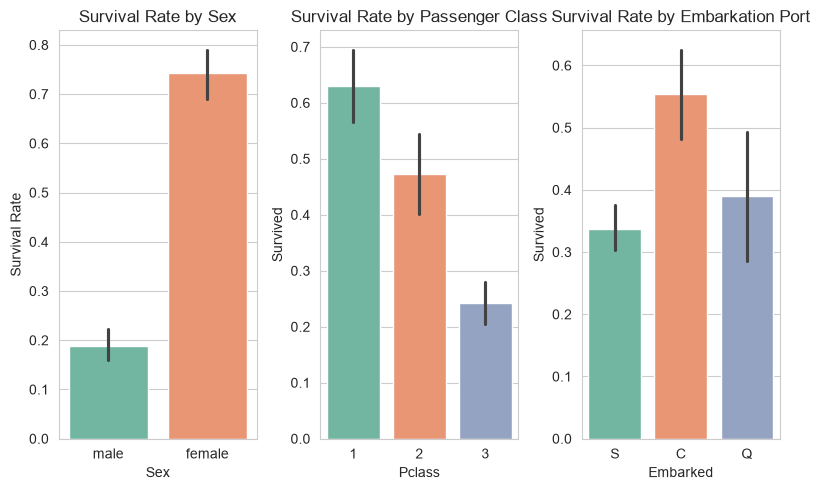

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [19]:
fig, ax = plt.subplots(1, 3, figsize = (8, 5))
sns.barplot(data = train, x = 'Sex', y = 'Survived', ax=ax[0], palette = 'Set2')
ax[0].set_title('Survival Rate by Sex')
ax[0].set_ylabel('Survival Rate')

sns.barplot(data = train, x='Pclass', y='Survived', ax=ax[1], palette = 'Set2')
ax[1].set_title('Survival Rate by Passenger Class')

sns.barplot(data = train, x='Embarked', y='Survived', ax=ax[2], palette='Set2')
ax[2].set_title("Survival Rate by Embarkation Port")

plt.tight_layout()
plt.show()

print(train.groupby('Sex')['Survived'].mean())
print()
print(train.groupby('Pclass')['Survived'].mean())

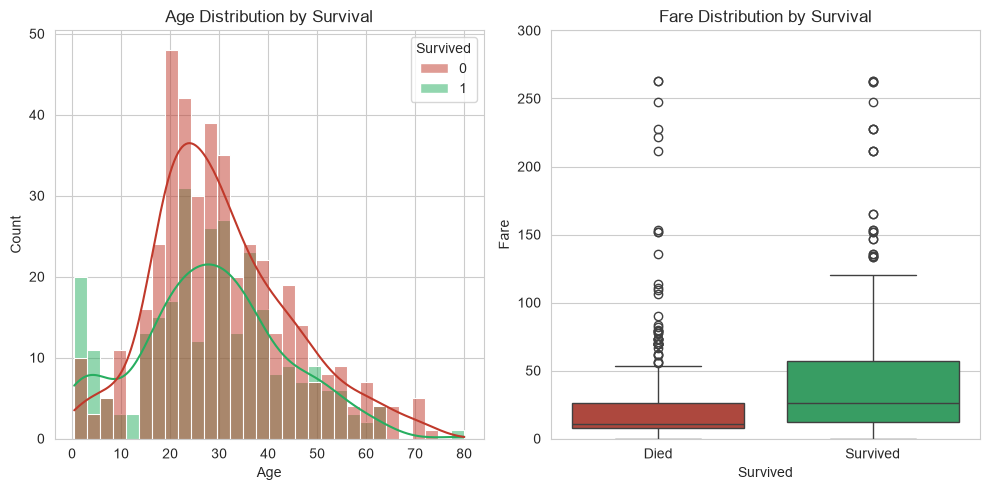

In [20]:
fig, ax = plt.subplots(1, 2, figsize = (10, 5))

sns.histplot(data = train, x= 'Age', hue='Survived', kde=True, bins=30, ax=ax[0], palette=['#c0392b', '#27ae60'])
ax[0].set_title('Age Distribution by Survival')

sns.boxplot(data = train, x='Survived', y='Fare', ax=ax[1], palette=['#c0392b', '#27ae60'])
ax[1].set_ylim(0, 300)
ax[1].set_title('Fare Distribution by Survival')
ax[1].set_xticklabels(['Died', 'Survived'])

plt.tight_layout()
plt.show()

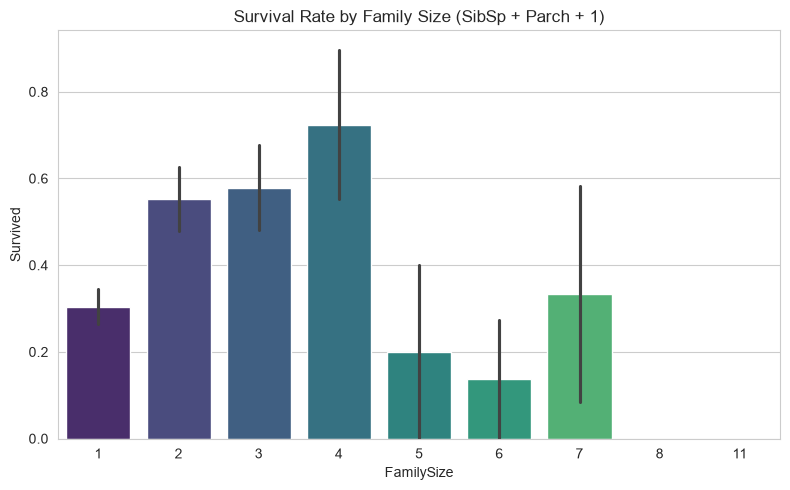

In [21]:
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1

fig, ax = plt.subplots(figsize = (8, 5))
sns.barplot(data = train, x='FamilySize', y='Survived', ax=ax, palette = 'viridis')
ax.set_title('Survival Rate by Family Size (SibSp + Parch + 1)')
plt.tight_layout()
plt.show()

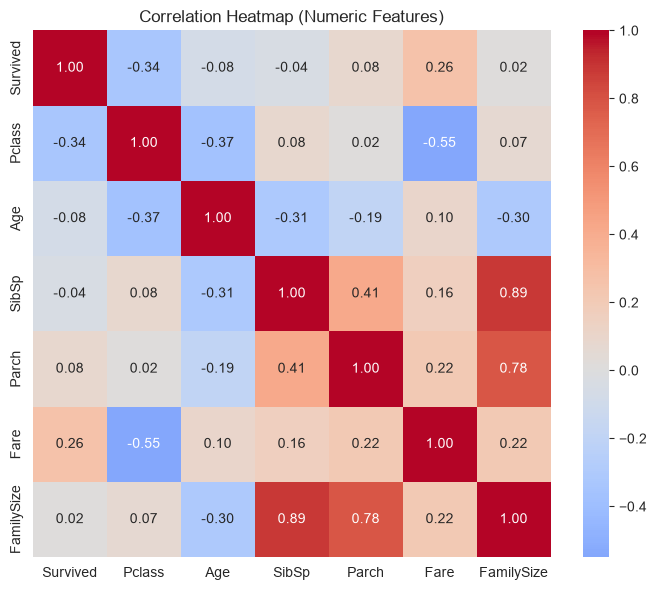

In [22]:
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
corr = train[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

**Key EDA takeaways**
- Women survived at a much higher rate than men.
- 1st class passengers survived far more often than 3rd class — `Pclass` and `Fare` matter.
- Small-to-medium families (2-4 members) survived more than solo travelers or very large families.
- `Age` has ~20% missing values and needs imputation; `Cabin` is mostly missing (~77%) and is best converted into a "Deck known / not known" feature rather than used raw.


## 3. Feature Engineering

We derive new features that are known to help on this dataset:
- **Title** extracted from the passenger's `Name` (Mr, Mrs, Miss, Master, Rare)
- **FamilySize** and **IsAlone**
- **Deck** extracted from the first letter of `Cabin` (`'Unknown'` when missing)
- **TicketGroupSize** — how many passengers share the same ticket number

All engineering is done with a reusable function so it is applied identically to train and test (no data leakage).

In [23]:
def engineer_features(df):
    df = df.copy()

    #Title from name
    df['Title'] = df['Name'].str.extract(r',\s*([^\.]*)\.')
    title_map = {
        'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
        'Lady': 'Rare', 'Countess': 'Rare', 'Capt': 'Rare', 'Col': 'Rare',
        'Don': 'Rare', 'Dr': 'Rare', 'Major': 'Rare', 'Rev': 'Rare',
        'Sir': 'Rare', 'Jonkheer': 'Rare', 'Dona': 'Rare'
    }
    df['Title'] = df['Title'].replace(title_map)
    df.loc[~df['Title'].isin(['Mr', 'Mrs', 'Miss', 'Master', 'Rare']), 'Title'] = 'Rare'

    # Family features
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # Deck from cabin
    df['Deck'] = df['Cabin'].str[0]
    df['Deck'] = df['Deck'].fillna('Unknown')

    # Ticket group size (people sharing the same ticket, incl. self)
    ticket_counts = df['Ticket'].value_counts()
    df['TicketGroupSize'] = df['Ticket'].map(ticket_counts)

    return df
train_fe = engineer_features(train)
test_fe = engineer_features(test)

print(train_fe['Title'].value_counts())
print()
print(train_fe['Deck'].value_counts())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64


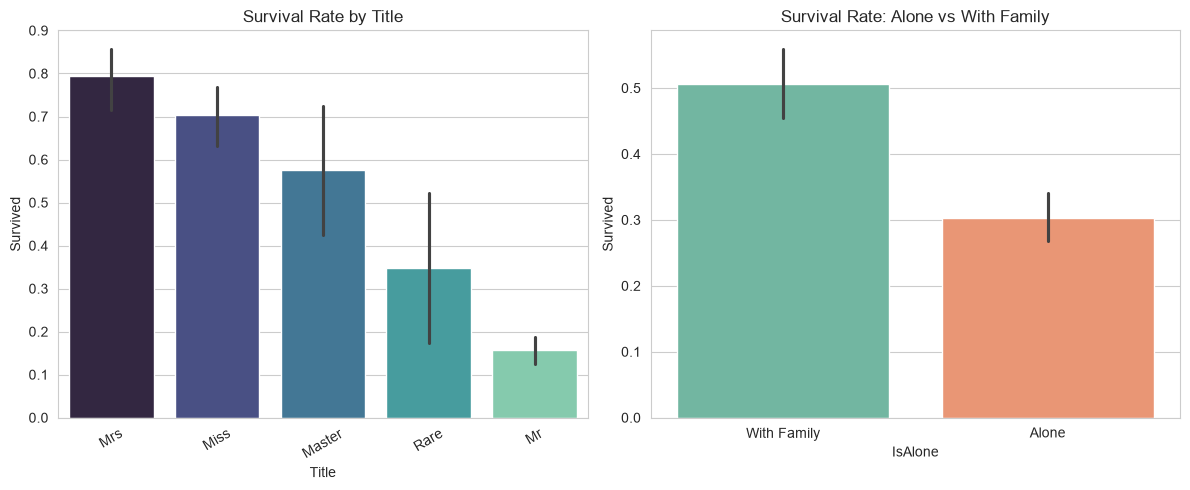

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data = train_fe, x='Title', y='Survived', ax=ax[0], palette='mako',
            order=train_fe.groupby('Title')['Survived'].mean().sort_values(ascending=False).index)
ax[0].set_title('Survival Rate by Title')
ax[0].tick_params(axis='x', rotation = 30)

sns.barplot(data = train_fe, x='IsAlone', y='Survived', ax=ax[1], palette='Set2')
ax[1].set_xticklabels(['With Family', 'Alone'])
ax[1].set_title('Survival Rate: Alone vs With Family')

plt.tight_layout()
plt.show()

## 4. Preprocessing Pipeline

We build a `ColumnTransformer` that:
- **Numeric features** (`Age`, `Fare`, `FamilySize`, `TicketGroupSize`): median imputation + standard scaling
- **Categorical features** (`Pclass`, `Sex`, `Embarked`, `Title`, `Deck`, `IsAlone`): most-frequent imputation + one-hot encoding

This is wrapped into a single `Pipeline` together with the classifier, so imputation/scaling statistics are learned **only on the training fold** during cross-validation — avoiding data leakage.

In [25]:
numeric_features = ['Age', 'Fare', 'FamilySize', 'TicketGroupSize']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title', 'Deck', 'IsAlone']

feature_cols = numeric_features + categorical_features

X = train_fe[feature_cols]
y = train_fe['Survived']
X_test_final = test_fe[feature_cols]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print('Train:', X_train.shape, 'Validation:', X_val.shape, 'Final test:', X_test_final.shape)

Train: (712, 10) Validation: (179, 10) Final test: (418, 10)


## 5. Multiple Models + Hyperparameter Tuning

We try 6 classifiers, each wrapped in the same preprocessing pipeline, and tune each with `GridSearchCV` (5-fold stratified CV, scored on accuracy).

In [26]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

model_grids = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        {'model__C': [0.01, 0.1, 1, 10], 'model__penalty': ['l2']}
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {'model__n_estimators': [200, 400], 'model__max_depth': [4, 6, 8, None],
         'model__min_samples_leaf': [1, 2, 4]}
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {'model__n_estimators': [100, 200], 'model__learning_rate': [0.03, 0.1],
         'model__max_depth': [2, 3, 4]}
    ),
    'SVM (RBF)': (
        SVC(probability=True, random_state=RANDOM_STATE),
        {'model__C': [0.5, 1, 5, 10], 'model__gamma': ['scale', 0.01, 0.1]}
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'model__n_neighbors': [5, 9, 13, 17], 'model__weights': ['uniform', 'distance']}
    ),
    'XGBoost': (
        XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE),
        {'model__n_estimators': [200, 400], 'model__max_depth': [3, 4, 5],
         'model__learning_rate': [0.03, 0.1]}
    ),
}

results = []
fitted_searches = {}

for name, (estimator, param_grid) in model_grids.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', estimator)])
    grid = GridSearchCV(pipe, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)

    val_pred = grid.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)

    results.append({
        'Model': name,
        'Best CV Accuracy': grid.best_score_,
        'Validation Accuracy': val_acc,
        'Best Params': grid.best_params_
    })
    fitted_searches[name] = grid
    print(f'{name:20s} | CV acc: {grid.best_score_:.4f} | Val acc: {val_acc:.4f}')

results_df = pd.DataFrame(results).sort_values('Validation Accuracy', ascending=False).reset_index(drop=True)
results_df[['Model', 'Best CV Accuracy', 'Validation Accuracy']]


Logistic Regression  | CV acc: 0.8273 | Val acc: 0.8380
Random Forest        | CV acc: 0.8315 | Val acc: 0.7989
Gradient Boosting    | CV acc: 0.8343 | Val acc: 0.8045
SVM (RBF)            | CV acc: 0.8399 | Val acc: 0.8268
KNN                  | CV acc: 0.8160 | Val acc: 0.8101
XGBoost              | CV acc: 0.8343 | Val acc: 0.8045


,Model,Best CV Accuracy,Validation Accuracy
0,Logistic Regression,0.827283,0.837989
1,SVM (RBF),0.839909,0.826816
2,KNN,0.816015,0.810056
3,Gradient Boosting,0.834295,0.804469
4,XGBoost,0.834285,0.804469
5,Random Forest,0.831488,0.798883


**Model Comparison Summary**
- 6 classification models were evaluated using CV and validation accuracy.
- SVM (RBF) achieved the highest CV accuracy: 83.99%.
- Logistic Regression achieved the highest Validation Accuracy: 83.80%.
- KNN achieved 81.60% CV and 81.01% validation accuracy.
- Gradient Boosting achieved 83.43% CV and 80.45% validation accuracy.
- XGBoost achieved 83.43% CV and 80.45% validation accuracy.
- Random Forest achieved 83.15% CV and 79.89% validation accuracy.
- Overall, Logistic Regression is the best model based on holdout validation performance.

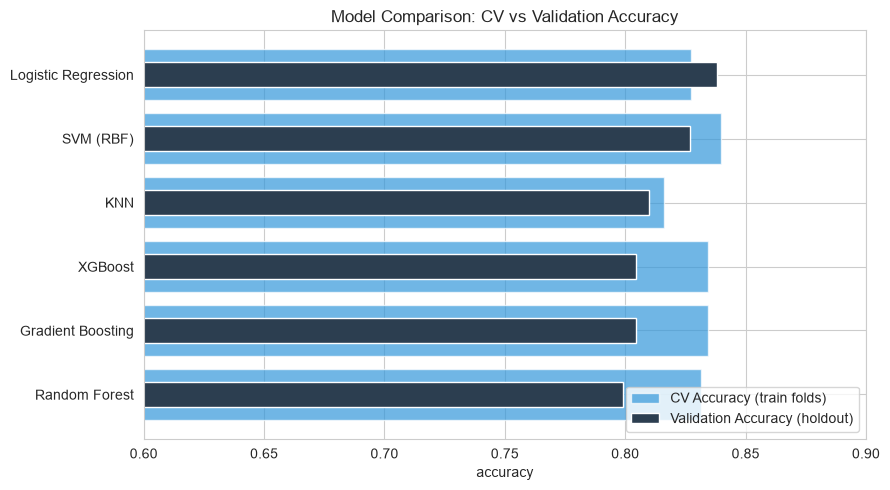

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = results_df.sort_values('Validation Accuracy')
ax.barh(plot_df['Model'], plot_df['Best CV Accuracy'], color='#3498db', alpha=0.7, label = 'CV Accuracy (train folds)')
ax.barh(plot_df['Model'], plot_df['Validation Accuracy'], color='#2c3e50', height=0.4, label='Validation Accuracy (holdout)')
ax.set_xlim(0.6, 0.9)
ax.set_xlabel('accuracy')
ax.set_title('Model Comparison: CV vs Validation Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Best Model — Detailed Evaluation

In [28]:
best_model_name = results_df.iloc[0]['Model']
best_search = fitted_searches[best_model_name]
best_pipeline = best_search.best_estimator_

print('Best Model:', best_model_name)
print('Best hyperparameters:', best_search.best_params_)
print('Best CV accuracy: {:.4f}'.format(best_search.best_score_))

y_val_pred = best_pipeline.predict(X_val)
y_val_proba = best_pipeline.predict_proba(X_val)[:, 1]

print()
print(classification_report(y_val, y_val_pred, target_names = ['Died', 'Survived']))
print('Validation ROC-AUC: {:.4f}'.format(roc_auc_score(y_val, y_val_proba)))

Best Model: Logistic Regression
Best hyperparameters: {'model__C': 1, 'model__penalty': 'l2'}
Best CV accuracy: 0.8273

              precision    recall  f1-score   support

        Died       0.85      0.89      0.87       110
    Survived       0.81      0.75      0.78        69

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179

Validation ROC-AUC: 0.8709


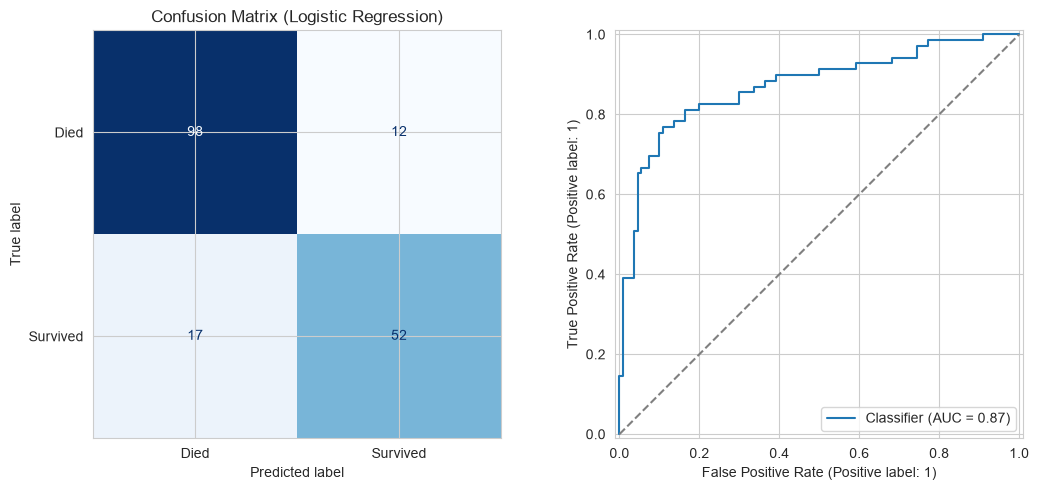

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(11, 5))

cm = confusion_matrix(y_val, y_val_pred)
ConfusionMatrixDisplay(cm, display_labels=['Died', 'Survived']).plot(ax=ax[0], cmap='Blues', colorbar=False)
ax[0].set_title(f'Confusion Matrix ({best_model_name})')

RocCurveDisplay.from_predictions(y_val, y_val_proba, ax=ax[1])
ax[1].plot([0, 1], [0, 1], linestyle='--', color = 'gray')

plt.tight_layout()
plt.show()

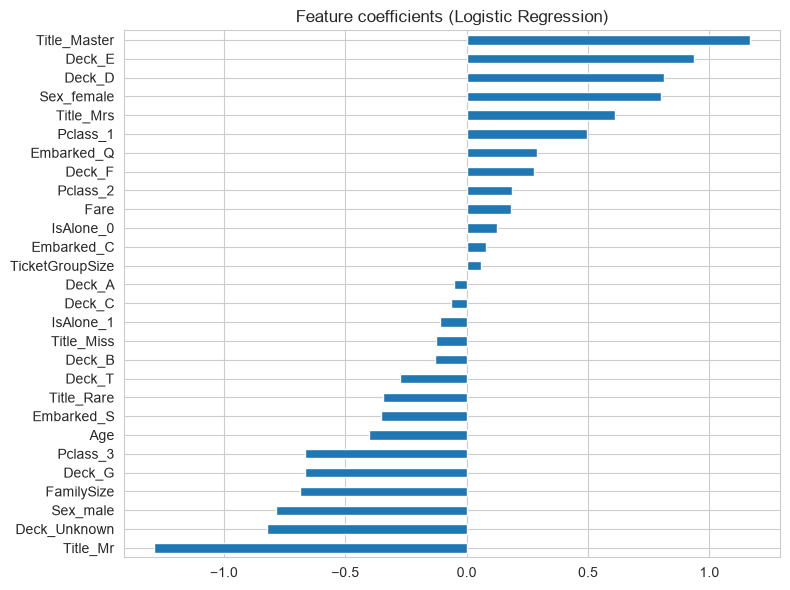

In [32]:
ohe_cols = best_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(ohe_cols)

model_step = best_pipeline.named_steps['model']

if hasattr(model_step, 'feature_importances_'):
    importances = pd.Series(model_step.feature_importances_, index=all_feature_names).sort_values(ascending=False).head(15)
    plt.figure(figsize=(8, 6))
    importances.sort_values().plot(kind='barh')
    plt.title(f'Top 15 Feature Importamces ({best_model_name})')
    plt.tight_layout()
    plt.show()
elif hasattr(model_step, 'coef_'):
    coefs = pd.Series(model_step.coef_[0], index=all_feature_names).sort_values()
    plt.figure(figsize=(8, 6))
    coefs.plot(kind='barh')
    plt.title(f'Feature coefficients ({best_model_name})')
    plt.tight_layout()
    plt.show()
else:
    print('Model does not expose feature importances / coefficients directly (e.g. SVM/KNN).')

## 7. Refit on Full Training Data & Predict on Test Set

**best pipeline (with its tuned hyperparameters)** on the *entire* labeled training set (train + validation combined), then predict on the official Kaggle `test.csv`.

In [36]:
final_pipeline = best_search.best_estimator_
final_pipeline.fit(X, y)

test_predictions = final_pipeline.predict(X_test_final)

submission = pd.DataFrame({
    'PassengerId': test_fe['PassengerId'],
    'Survived': test_predictions
})

submission.to_csv('submission.csv', index=False)
print('Saved submission.csv with shape:', submission.shape)
submission.head(10)

Saved submission.csv with shape: (418, 2)


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


In [35]:
print('Predicted survival rate on test set: {:.1f}%'.format(submission['Survived'].mean() * 100))
print('Training survival rate               : {:.1f}%'.format(train['Survived'].mean() * 100))

agreement = (submission['Survived'].values == gender_submission['Survived'].values).mean()
print(f"Agreement with the baseline 'gender_submission.csv' (women-survive heuristic): {agreement*100:.1f}%")


Predicted survival rate on test set: 40.4%
Training survival rate               : 38.4%
Agreement with the baseline 'gender_submission.csv' (women-survive heuristic): 92.1%


## 8. Summary

| Step | What we did |
|---|---|
| EDA | Found `Sex`, `Pclass`, `Fare`, `Age`, family size all correlate with survival |
| Feature Engineering | `Title`, `FamilySize`, `IsAlone`, `Deck`, `TicketGroupSize` |
| Pipeline | `ColumnTransformer` (median/most-frequent imputation, scaling, one-hot) inside a single `Pipeline` — no leakage |
| Models tried | Logistic Regression, Random Forest, Gradient Boosting, SVM, KNN, XGBoost |
| Tuning | 5-fold `GridSearchCV` per model, scored on accuracy |
| Result | Best model and its validation accuracy/ROC-AUC are printed above; `submission.csv` is ready to upload to Kaggle |

**Ideas to push accuracy further:**
- Try `RandomizedSearchCV` / Bayesian search (Optuna) over a wider hyperparameter space
- Stack/blend the top 2-3 models (`VotingClassifier` or `StackingClassifier`)
- Engineer fare-per-person, cabin multiplicity, or name-length features
- Use `Age` prediction via a small regression model (instead of median imputation) based on `Title`/`Pclass`
